In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
np.random.seed(42)
# Data Generation
N = 200

cycles = np.arange(N)


# ESR DEGRADATION


ESR = (
    0.12
    + 0.0006 * cycles
    + 0.000004 * (cycles ** 2)
    + 0.003 * np.sin(cycles / 12)
    + np.random.normal(0, 0.0015, N)
)


# CAPACITANCE DEGRADATION


Capacitance = (
    1000
    - 0.55 * cycles
    - 0.003 * (cycles ** 2)
    + 2 * np.sin(cycles / 15)
    + np.random.normal(0, 1.5, N)
)


# IMPEDANCE FEATURE


Impedance = (
    ESR * 4.2
    + 0.01 * np.sin(cycles / 9)
    + np.random.normal(0, 0.004, N)
)


# HEALTH INDICATOR
# Higher ESR -> lower health


HI = 1 - (
    (ESR - ESR.min())
    /
    (ESR.max() - ESR.min())
)

In [ ]:

# FAILURE THRESHOLD

failure_threshold = 0.37

failure_idx = np.argmax(ESR >= failure_threshold)

if failure_idx == 0:
    failure_idx = N - 1


# RUL GENERATION


RUL = failure_idx - cycles

RUL[RUL < 0] = 0


# CREATE DATAFRAME


data = pd.DataFrame({
    'Cycle': cycles,
    'ESR': ESR,
    'Capacitance': Capacitance,
    'Impedance': Impedance,
    'HI': HI,
    'RUL': RUL
})

print("\nDATASET PREVIEW\n")

print(data.head())



DATASET PREVIEW

   Cycle       ESR  Capacitance  Impedance        HI  RUL
0      0  0.120745  1000.536681   0.500752  0.999638  186
1      1  0.120646  1000.421411   0.505426  1.000000  185
2      2  0.122685  1000.778454   0.517503  0.992535  184
3      3  0.124863  1000.301042   0.527883  0.984563  183
4      4  0.123094   996.212531   0.519496  0.991037  182


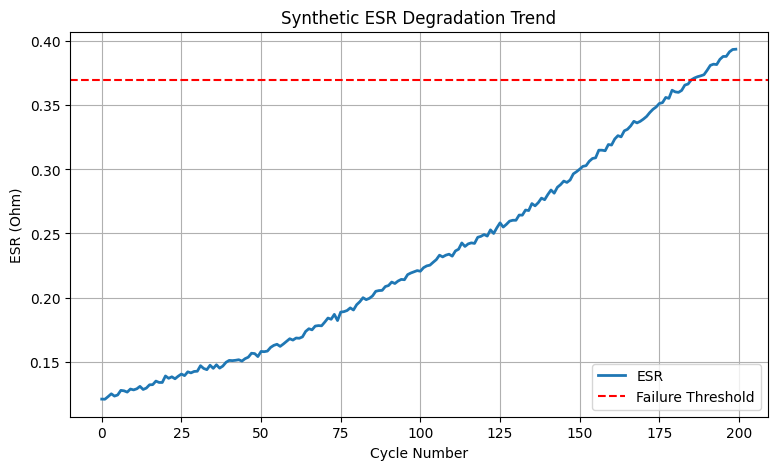

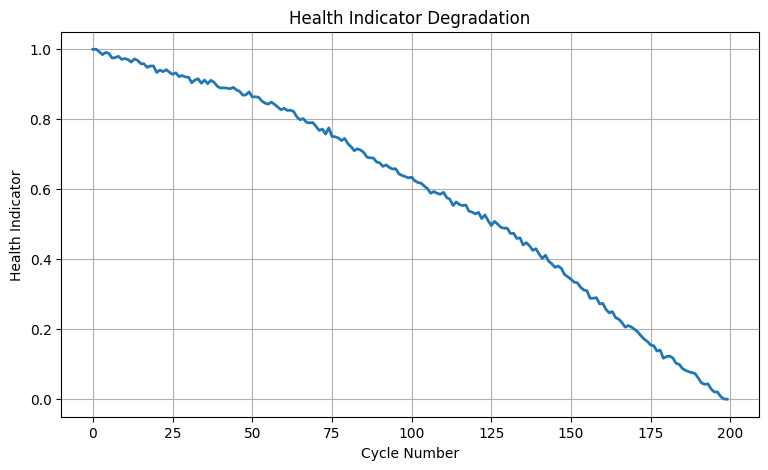

In [ ]:
# ESR TREND


plt.figure(figsize=(9,5))

plt.plot(
    cycles,
    ESR,
    linewidth=2,
    label='ESR'
)

plt.axhline(
    failure_threshold,
    color='r',
    linestyle='--',
    label='Failure Threshold'
)

plt.xlabel('Cycle Number')

plt.ylabel('ESR (Ohm)')

plt.title('Synthetic ESR Degradation Trend')

plt.legend()

plt.grid(True)

plt.show()

# HEALTH INDICATOR TREND


plt.figure(figsize=(9,5))

plt.plot(
    cycles,
    HI,
    linewidth=2
)

plt.xlabel('Cycle Number')

plt.ylabel('Health Indicator')

plt.title('Health Indicator Degradation')

plt.grid(True)

plt.show()

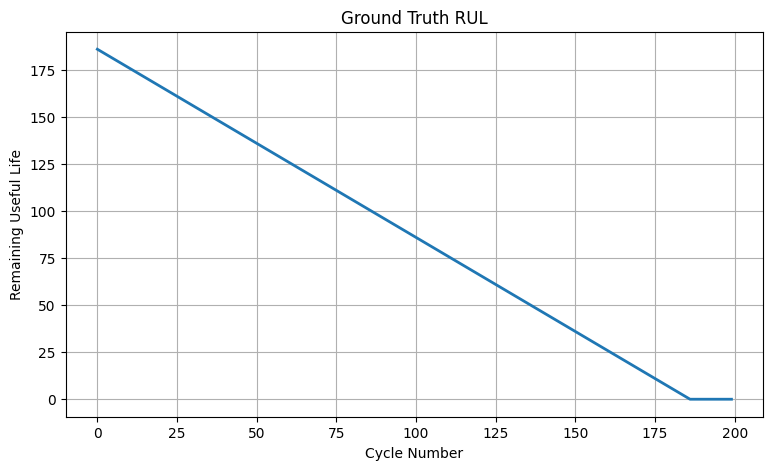

In [ ]:
# GROUND TRUTH RUL


plt.figure(figsize=(9,5))

plt.plot(
    cycles,
    RUL,
    linewidth=2
)

plt.xlabel('Cycle Number')

plt.ylabel('Remaining Useful Life')

plt.title('Ground Truth RUL')

plt.grid(True)

plt.show()

In [ ]:

# FEATURE SELECTION


X = data[[
    'ESR',
    'Capacitance',
    'Impedance',
    'HI'
]]

y = data['RUL']


# TRAIN / TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

print("\nTraining Samples :", len(X_train))

print("Testing Samples  :", len(X_test))



Training Samples : 150
Testing Samples  : 50


In [ ]:

# MACHINE LEARNING MODEL


model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)


# PREDICTION

y_pred = model.predict(X_test)


# MODEL EVALUATION


mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)


print("MODEL PERFORMANCE")


print(f"MAE       : {mae:.2f}")

print(f"RMSE      : {rmse:.2f}")

print(f"R2 Score  : {r2:.4f}")

MODEL PERFORMANCE
MAE       : 1.07
RMSE      : 1.32
R2 Score  : 0.9994


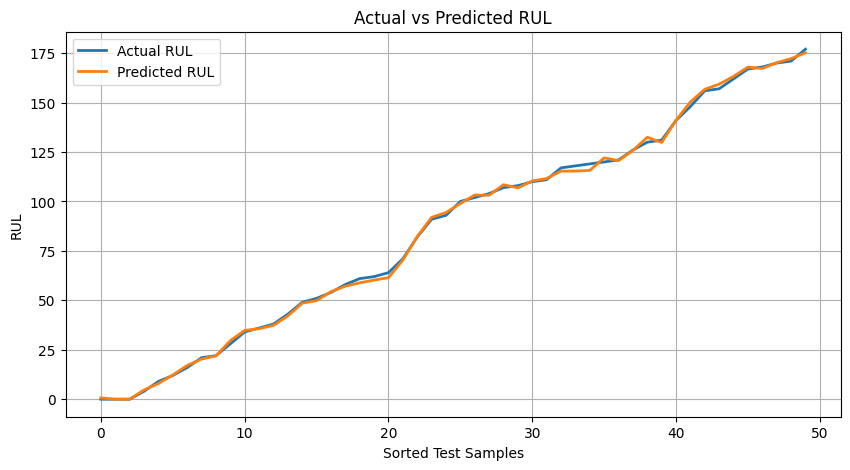

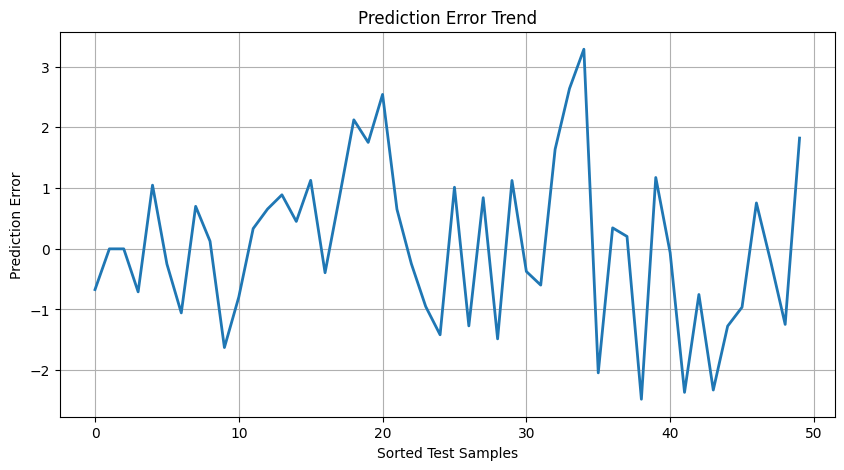

In [ ]:
# ACTUAL vs PREDICTED RUL


sorted_idx = np.argsort(y_test.values)

y_test_sorted = y_test.values[sorted_idx]

y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10,5))

plt.plot(
    y_test_sorted,
    linewidth=2,
    label='Actual RUL'
)

plt.plot(
    y_pred_sorted,
    linewidth=2,
    label='Predicted RUL'
)

plt.xlabel('Sorted Test Samples')

plt.ylabel('RUL')

plt.title('Actual vs Predicted RUL')

plt.legend()

plt.grid(True)

plt.show()

# PREDICTION ERROR


error = y_test_sorted - y_pred_sorted

plt.figure(figsize=(10,5))

plt.plot(
    error,
    linewidth=2
)

plt.xlabel('Sorted Test Samples')

plt.ylabel('Prediction Error')

plt.title('Prediction Error Trend')

plt.grid(True)

plt.show()

In [ ]:
# FINAL OUTPUT


print("REALISTIC SYNTHETIC PROGNOSTICS COMPLETED")


print(f"\nFailure Cycle : {failure_idx}")

print(f"Initial ESR   : {ESR[0]:.4f} Ohm")

print(f"Final ESR     : {ESR[-1]:.4f} Ohm")

REALISTIC SYNTHETIC PROGNOSTICS COMPLETED

Failure Cycle : 186
Initial ESR   : 0.1207 Ohm
Final ESR     : 0.3938 Ohm
